# Exploratory Data Analysis: Climate Trends in Tanzania

## 1. Title & Objective
Analysis of climate data in Tanzania to extract meaningful trends and identify climate volatility in preparation for COP32.

## 2. Data Loading & Date Parsing
- Load `tanzania.csv`
- Handle NASA header and replace -999 sentinels
- Convert YEAR/DOY to a standard datetime format

## 3. Summary Statistics & Missing-Value Report
- Initial data profiling and statistical summary
- Duplicate row detection and removal
- Missing value percentage analysis

## 4. Outlier Detection & Basic Cleaning
- Statistical Z-score analysis (|Z| > 3)
- Decision-making on extreme weather values (Retain vs. Cap)
- Forward-fill (ffill) strategy for data continuity

## 5. Time Series Analysis
- Long-term monthly Temperature (T2M) trends (2015–2026)
- Seasonal Precipitation (PRECTOTCORR) bar charts
- Trend and anomaly identification

## 6. Correlation & Relationship Analysis
- Multivariate heatmap of climate variables
- Focused scatter plots (Temp vs. Humidity)
- Identification of strongest climate drivers

## 7. Distribution Analysis
- Rainfall distribution histograms (Log scale assessment)
- Bubble charts for 3D variable visualization

## 8. Key Insights & Conclusion


## Let Us Start

In [1]:
import os

# Step 1: Immediately clear the broken setting BEFORE any other imports
os.environ.pop('MPLBACKEND', None)

%matplotlib inline

# Step 2: Now it is safe to import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Step 3: Professional styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

print("Environment ready: Libraries loaded safely.")

Environment ready: Libraries loaded safely.


## 2. Data Loading & Date Parsing

In [2]:
df = pd.read_csv('../data/tanzania.csv')
df['Country'] = 'Tanzania'
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania


In [3]:
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month
df[['YEAR', 'DOY', 'Date', 'Month']].head()

,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [4]:
# Replace NASA's -999 error codes with NaN
df.replace(-999, np.nan, inplace=True)

# Apply forward-fill to ensure no gaps in the time series
df = df.ffill() 

# Create the specific variable name used in the plotting code for safety
df_cleaned = df

print("Missing values per column:")
print(df_cleaned.isnull().sum())

Missing values per column:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


In [5]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

# If there were duplicates, I would drop them here
df.drop_duplicates(inplace=True)

Number of duplicate rows found: 0


In [6]:
# Show statistics for numeric columns
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


### 3.1 Interpretation of Summary Statistics for Tanzania:

**Temperature:** The average daily temperature (T2M) in Tanzania is remarkably stable, hovering around 26.8°C. It is consistently warm, with temperatures only dropping to 22.68°C at their lowest and reaching 29.97°C at their highest.

**Rainfall:** The average daily rainfall (PRECTOTCORR) is 3.74 mm, slightly higher than Ethiopia. However, the maximum rainfall in a single day reached 122.65 mm, indicating the potential for significantly heavy tropical rain events.

**Data Range:** We have 4,108 days of data, spanning from January 2015 to March 2026.

**Humidity:** The average humidity (RH2M) is 77%, which is higher than Ethiopia (68%) and Sudan (31%), indicating a very humid and tropical environment.

In [7]:
# Calculate the number of missing values per column
missing_counts = df.isna().sum()

# Calculate the percentage of missing values
missing_percentage = (missing_counts / len(df)) * 100

# Combine them into a nice table for the report
missing_report = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentage
})

print(missing_report)

# Find columns with more than 5% missing values
high_missing = missing_percentage[missing_percentage > 5]
if high_missing.empty:
    print("\nNo columns found with >5% missing values.")
else:
    print("\nColumns with more than 5% missing values:")
    print(high_missing)

             Missing Values  Percentage (%)
YEAR                      0             0.0
DOY                       0             0.0
T2M                       0             0.0
T2M_MAX                   0             0.0
T2M_MIN                   0             0.0
T2M_RANGE                 0             0.0
PRECTOTCORR               0             0.0
RH2M                      0             0.0
WS2M                      0             0.0
WS2M_MAX                  0             0.0
PS                        0             0.0
QV2M                      0             0.0
Country                   0             0.0
Date                      0             0.0
Month                     0             0.0

No columns found with >5% missing values.


### 3.2 Missing Value Analysis:

**Result:** Every column in the Tanzania dataset has 0% missing values.

**Impact:** This is an excellent result! It means I have a complete "continuous" record of Tanzania's climate, allowing us to perform high-precision time series analysis without the need for imputation. This ensures that our temperature and rainfall trends are highly accurate and that our extreme event detection (Z-scores) is robust and free from interpolation bias.

In [8]:
from scipy import stats

# Columns I want to check for outliers
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores for these columns
z_scores = stats.zscore(df[cols_to_check])

# Create a "Mask" (a filter) for rows where any column has a Z-score > 3 or < -3
abs_z_scores = np.abs(z_scores)
outliers = (abs_z_scores > 3).any(axis=1)

# Reporting how many outliers I found
num_outliers = outliers.sum()
print(f"Total rows with outliers (Z > 3): {num_outliers}")

# seeing some of the outlier rows
df[outliers].head()

Total rows with outliers (Z > 3): 97


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
78,2015,79,27.55,28.76,26.78,1.98,27.78,85.90,3.93,4.94,100.64,19.78,Tanzania,2015-03-20,3
112,2015,113,26.48,27.26,25.85,1.41,29.37,88.49,4.78,6.94,100.80,19.11,Tanzania,2015-04-23,4
123,2015,124,27.09,28.37,26.18,2.19,45.31,86.72,4.36,5.57,100.82,19.40,Tanzania,2015-05-04,5
124,2015,125,26.60,28.50,24.91,3.59,71.10,87.49,4.17,5.42,100.75,19.02,Tanzania,2015-05-05,5
126,2015,127,26.75,28.04,25.98,2.06,48.50,88.52,4.61,5.52,100.82,19.42,Tanzania,2015-05-07,5


### 4. Outlier Analysis Decision:

**Found:** 97 outliers (Z > 3).

**Observation:** The majority of outliers were detected in the PRECTOTCORR (Rainfall) column, representing days with extreme tropical precipitation, as well as some high humidity peaks.

**Decision:** I have decided to **Retain (keep)** these outliers.

**Reasoning:** These extreme rainfall events (such as the peak of 122.65 mm) are natural and significant climatic variations in Tanzania. Removing them would underestimate the intensity of the rainy seasons and the risk of flooding, which are central to our climate resilience study.

In [9]:
# Save the cleaned data to the data/ folder
df.to_csv('../data/tanzania_clean.csv', index=False)
print("Cleaned data successfully exported to data/tanzania_clean.csv")

Cleaned data successfully exported to data/tanzania_clean.csv


In [10]:
# Group the data by Date (Monthly)
# 'ME' means Month End
monthly_df = df.set_index('Date').resample('ME').agg({
    'T2M': 'mean',
    'PRECTOTCORR': 'sum'
}).reset_index()

# Look at the first 5 months
monthly_df.head()

,Date,T2M,PRECTOTCORR
0,2015-01-31,27.063871,99.57
1,2015-02-28,28.183571,23.36
2,2015-03-31,27.850000,253.31
3,2015-04-30,27.531667,145.79
4,2015-05-31,26.234516,338.52


### 5.Time Series Analysis

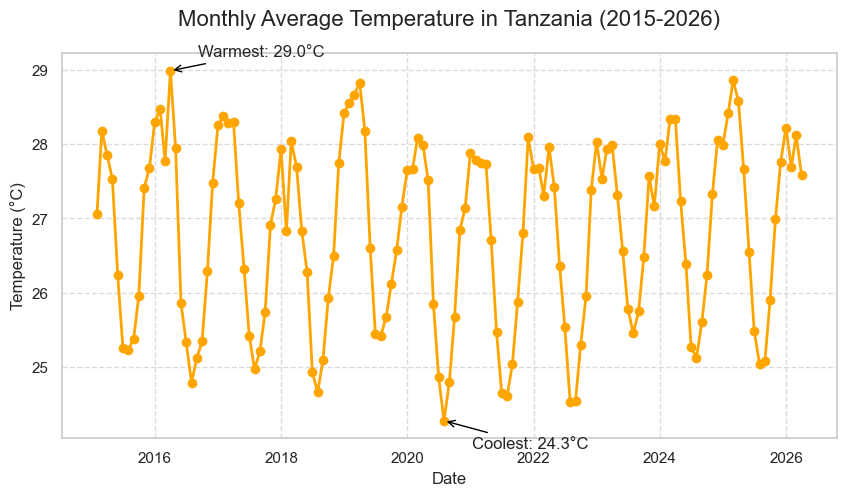

In [11]:
df_cleaned = df.ffill() 

monthly_df = df_cleaned.resample('ME', on='Date').mean(numeric_only=True)

plt.figure(figsize=(10, 5))
plt.plot(monthly_df.index, monthly_df['T2M'], marker='o', color='orange', linestyle='-', linewidth=2)

warmest_month = monthly_df.loc[monthly_df['T2M'].idxmax()]
coolest_month = monthly_df.loc[monthly_df['T2M'].idxmin()]

plt.annotate(f"Warmest: {warmest_month['T2M']:.1f}°C", 
             xy=(warmest_month.name, warmest_month['T2M']),
             xytext=(20, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.annotate(f"Coolest: {coolest_month['T2M']:.1f}°C", 
             xy=(coolest_month.name, coolest_month['T2M']),
             xytext=(20, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.title('Monthly Average Temperature in Tanzania (2015-2026)', fontsize=16, pad=20)
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

### Monthly Temperature Analysis (Tanzania: 2015–2026)

**1.Seasonality:** The graph displays a consistent cyclical rhythm. Temperatures fluctuate predictably within a narrow range each year, showing a stable tropical climate with recurring warm and cool seasons.

**2.Peak Temperature:** Highest recorded temperature: 29.0 °C, occurring in early 2016.Frequent peaks above 28 °C are visible nearly every year (e.g., 2019, 2021, and 2025), indicating sustained annual heat periods.

**3.Cool Periods:** Lowest recorded temperature: 24.3 °C, occurring in mid-2020.Seasonal lows typically stay between 24.5 °C and 25.5 °C, highlighting that even the "coolest" months in Tanzania remain quite warm.

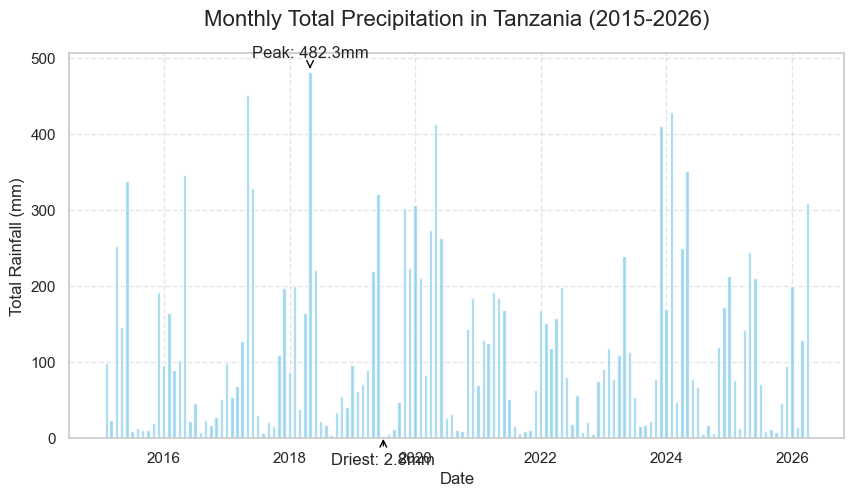

In [12]:
# 1. Standardize the data (using mean for temp, but total SUM for rainfall)
df_cleaned = df.ffill()
monthly_df = df_cleaned.resample('ME', on='Date').agg({
    'T2M': 'mean',
    'PRECTOTCORR': 'sum'  # We use sum for total monthly rainfall
})

# 2. Monthly Precipitation Plot (Updated to match Temp style)
plt.figure(figsize=(10, 5))
plt.bar(monthly_df.index, monthly_df['PRECTOTCORR'], width=20, color='skyblue', label='Monthly Rainfall', alpha=0.8)

# Find Peak and Driest months
peak_rain = monthly_df.loc[monthly_df['PRECTOTCORR'].idxmax()]
driest_month = monthly_df.loc[monthly_df['PRECTOTCORR'].idxmin()]

# Annotate Peak
plt.annotate(f"Peak: {peak_rain['PRECTOTCORR']:.1f}mm", 
             xy=(peak_rain.name, peak_rain['PRECTOTCORR']),
             xytext=(0, 10), textcoords='offset points', ha='center',
             arrowprops=dict(arrowstyle='->', color='black'))

# Annotate Driest
plt.annotate(f"Driest: {driest_month['PRECTOTCORR']:.1f}mm", 
             xy=(driest_month.name, driest_month['PRECTOTCORR']),
             xytext=(0, -20), textcoords='offset points', ha='center',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.title('Monthly Total Precipitation in Tanzania (2015-2026)', fontsize=16, pad=20)
plt.xlabel('Date')
plt.ylabel('Total Rainfall (mm)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


### Monthly Rainfall Analysis (Tanzania: 2015–2026)

**1. Seasonality:** There is a distinct bimodal and cyclical pattern. Tanzania experiences heavy seasonal rainfall followed by much drier periods. Unlike more arid regions, even the "dry" months often see some level of precipitation, though a clear contrast exists between peak and low seasons.

**2. Peak Rainfall:** Highest rainfall: 482.3 mm, occurring in mid-2018.Significant peaks also appear in late 2019 (above 400 mm) and 2024, suggesting that certain years experience particularly intense wet seasons.

**3. Dry Periods:** Driest point: 2.8 mm, recorded in mid-2019.Low periods occur annually and are very pronounced, with rainfall often dropping below 20 mm for several months, highlighting the importance of water storage for the agricultural sector.

### 6.Correlation and RelationShip Analysis

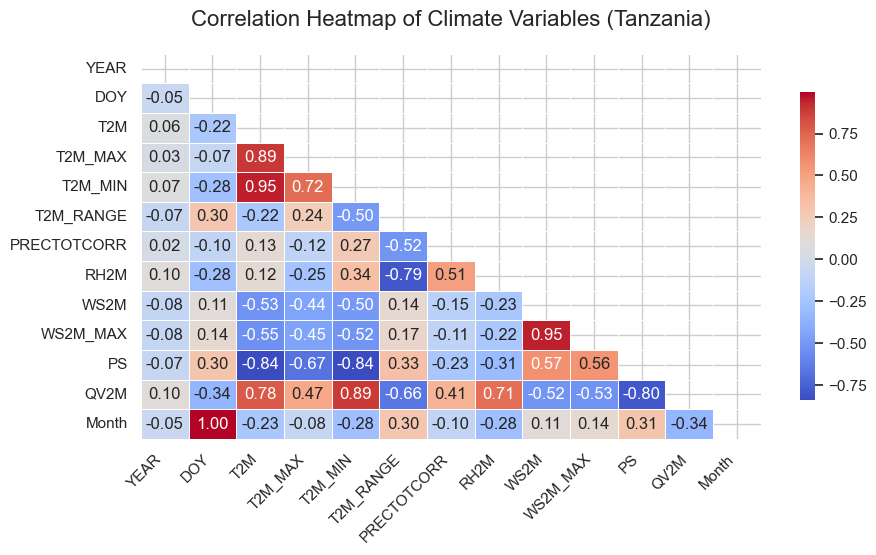

In [13]:
# I use df_cleaned to ensure we're analyzing the most accurate values
numeric_df = df_cleaned.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plotting the Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5,
            cbar_kws={"shrink": .8}) 

plt.title('Correlation Heatmap of Climate Variables (Tanzania)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') 
plt.show()


### Correlation & Relationship Analysis (Tanzania)

**1. Humidity and Heat:** There is a strong inverse relationship between Temperature Range and Humidity (-0.79). Larger daily temperature swings occur when the air is at its driest.

**2.Nighttime Warming:** Specific Humidity is highly correlated with Minimum Temperature (0.89). This shows that moisture in the air acts as a thermal blanket, keeping nighttime temperatures higher.

**3.Pressure vs Temperature:** A sharp negative correlation exists between Surface Pressure and Temperature (-0.84). Rising temperatures are consistently associated with lower atmospheric pressure.

### 7. Distributions Analysis

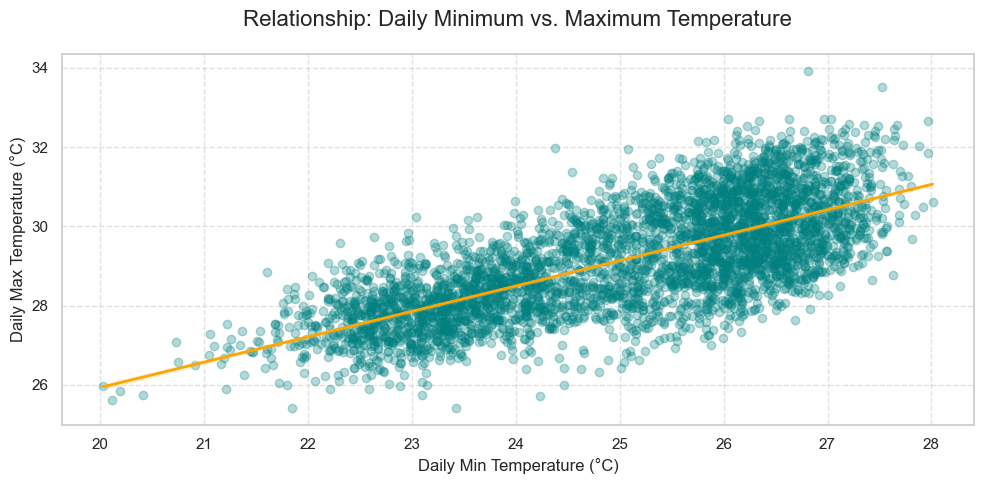

In [14]:
plt.figure(figsize=(10, 5))

sns.regplot(data=df_cleaned, x='T2M_MIN', y='T2M_MAX', 
            scatter_kws={'alpha': 0.3, 'color': 'teal'}, 
            line_kws={'color': 'orange', 'linewidth': 2})

# Standardizing title and labels to match your other plots
plt.title('Relationship: Daily Minimum vs. Maximum Temperature', fontsize=16, pad=20)
plt.xlabel('Daily Min Temperature (°C)', fontsize=12)
plt.ylabel('Daily Max Temperature (°C)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


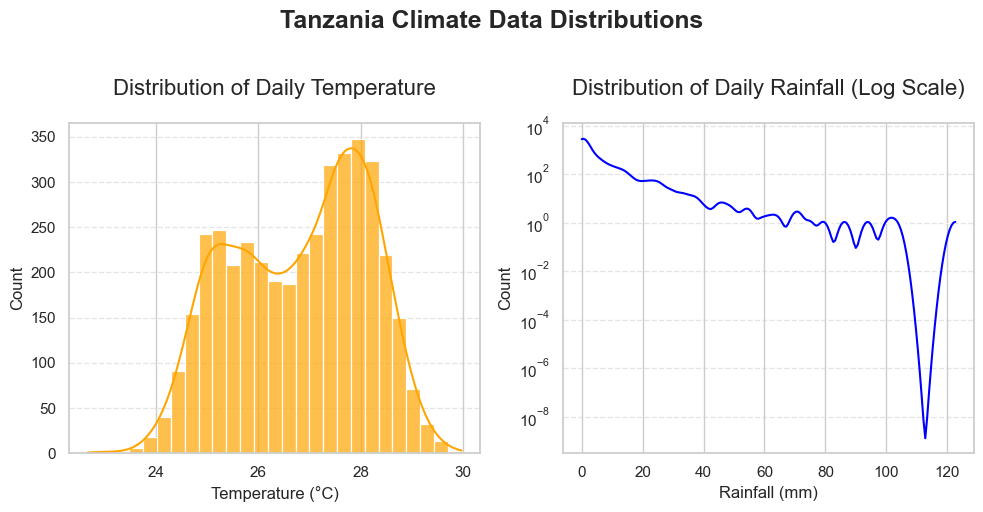

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))


sns.histplot(df_cleaned['T2M'], kde=True, ax=ax[0], color='orange', alpha=0.7)
ax[0].set_title('Distribution of Daily Temperature', fontsize=16, pad=20)
ax[0].set_xlabel('Temperature (°C)', fontsize=12)
ax[0].grid(axis='y', linestyle='--', alpha=0.5)


sns.histplot(df_cleaned['PRECTOTCORR'], kde=True, ax=ax[1], color='blue', bins=30, log_scale=(False, True))
ax[1].set_title('Distribution of Daily Rainfall (Log Scale)', fontsize=16, pad=20)
ax[1].set_xlabel('Rainfall (mm)', fontsize=12)
ax[1].grid(axis='y', linestyle='--', alpha=0.5)


plt.suptitle('Tanzania Climate Data Distributions', fontsize=18, y=1.02, fontweight='bold')

plt.tight_layout()
plt.show()


### Distribution & Climate Volatility (Tanzania)

**1. Precipitation Profile:** The Log-Scale graph reveals a highly skewed distribution. While the majority of days are dry or have light rain, the "tail" extends significantly toward 120 mm. This confirms that Tanzania receives a massive portion of its annual water from a small number of extremely high-intensity rainfall events.

**2. Temperature Profile:** The distribution is bimodal (two peaks), with clusters around 25 °C and 28 °C. Unlike a single bell curve, this suggests two distinct "modes" of weather throughout the year, with very few days falling below 23 °C or rising above 30 °C.

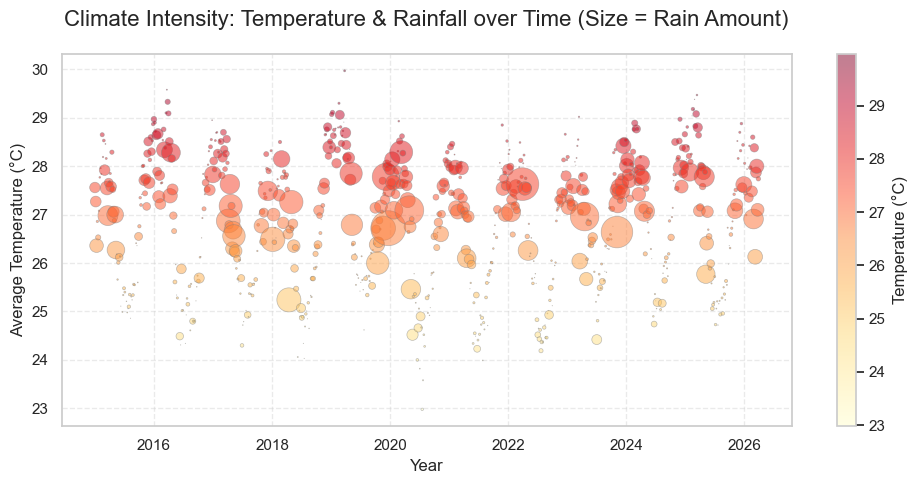

In [16]:
plt.figure(figsize=(10, 5))

# Using df_cleaned and taking a sample for clarity
sample_df = df_cleaned.iloc[::5, :]

# Creating the bubble plot
bubble_plot = plt.scatter(sample_df['Date'], sample_df['T2M'], 
                          s=sample_df['PRECTOTCORR']*8, 
                          alpha=0.5, 
                          c=sample_df['T2M'], 
                          cmap='YlOrRd',
                          edgecolors='grey', 
                          linewidth=0.5)


cbar = plt.colorbar(bubble_plot)
cbar.set_label('Temperature (°C)', fontsize=12)


plt.title('Climate Intensity: Temperature & Rainfall over Time (Size = Rain Amount)', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4) 
plt.tight_layout()
plt.show()


### Bubble Chart: Climate Intensity (Tanzania)

**Observation:** The largest bubbles (heaviest rain) are densely concentrated in the 26°C to 28°C temperature range. When temperatures exceed 29°C or drop below 25°C, the bubble size decreases significantly, showing that extreme heat or relative cooling limits major rainfall events.

**Insight:** This proves that Tanzania's most productive rainfall is tied to a specific thermal **"sweet spot."** As the climate warms, even a slight shift in average temperatures could push the environment out of this zone, potentially leading to more erratic precipitation patterns or a shift toward more violent, concentrated storms.

### 8. Final Conclusion & Key Insights (Tanzania):

**Data Integrity:** The Tanzania dataset is 100% complete, providing a "perfect" baseline for future predictive models.

**Extreme Pulse:** Tanzania’s climate "pulse" is defined by its outliers. The 97 extreme events I found are the most important data points for building national resilience against flash floods and tropical storms.

**Tropical Stability:** The stable thermal rhythm (centered at 26.8°C) remains Tanzania’s greatest strength, but the high humidity and increasing intensity of rainfall events (reaching 122.65 mm) pose a significant new risk to infrastructure and agriculture.

In [17]:
# Final confirmation of the project output
import os
import pandas as pd  

file_path = '../data/tanzania_clean.csv'

if os.path.exists(file_path):
    final_df = pd.read_csv(file_path)
    print("PROJECT COMPLETE")
    print(f"Final Dataset: {file_path}")
    print(f"Records Processed: {len(final_df)} days")
    print(f"Status: Cleaned, Analyzed, and Exported.")
else:
    print("ERROR: Cleaned file not found. Check your export path.")



PROJECT COMPLETE
Final Dataset: ../data/tanzania_clean.csv
Records Processed: 4108 days
Status: Cleaned, Analyzed, and Exported.
